# Predicting House Prices with Linear Regression

**Objective:** Build and evaluate a linear regression model that predicts house prices from features like area, location, rooms, and age — covering the full workflow from EDA through model interpretation.

**Dataset:** `data/house_prices.csv` — 2,000 houses, 10 columns (Kaggle "House Price Prediction Dataset").

**Tech stack:** Python, pandas, scikit-learn, matplotlib, seaborn


## 1. Load Dataset & Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('../data/house_prices.csv')
df.head()


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [2]:
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print()
df.info()


Shape: 2000 rows, 10 columns

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Id         2000 non-null   int64
 1   Area       2000 non-null   int64
 2   Bedrooms   2000 non-null   int64
 3   Bathrooms  2000 non-null   int64
 4   Floors     2000 non-null   int64
 5   YearBuilt  2000 non-null   int64
 6   Location   2000 non-null   str  
 7   Condition  2000 non-null   str  
 8   Garage     2000 non-null   str  
 9   Price      2000 non-null   int64
dtypes: int64(7), str(3)
memory usage: 156.4 KB


In [3]:
df.isnull().sum().to_frame(name='null_count')


,null_count
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


In [4]:
df.describe().round(2)


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,1000.50,2786.21,3.00,2.55,1.99,1961.45,537676.86
std,577.49,1295.15,1.42,1.11,0.81,35.93,276428.85
min,1.00,501.00,1.00,1.00,1.00,1900.00,50005.00
25%,500.75,1653.00,2.00,2.00,1.00,1930.00,300098.00
50%,1000.50,2833.00,3.00,3.00,2.00,1961.00,539254.00
75%,1500.25,3887.50,4.00,4.00,3.00,1993.00,780086.00
max,2000.00,4999.00,5.00,4.00,3.00,2023.00,999656.00


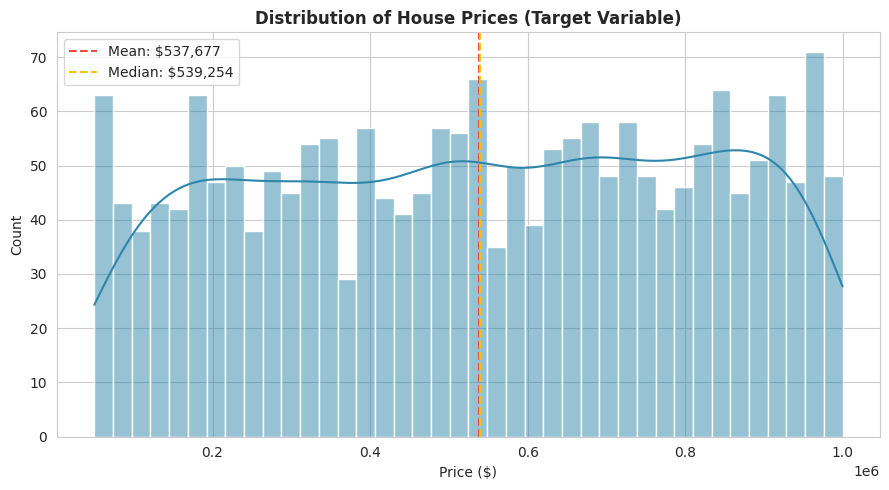

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df['Price'], bins=40, kde=True, color='#2E86AB', ax=ax)
ax.axvline(df['Price'].mean(), color='#E74C3C', linestyle='--', label=f"Mean: ${df['Price'].mean():,.0f}")
ax.axvline(df['Price'].median(), color='#F1C40F', linestyle='--', label=f"Median: ${df['Price'].median():,.0f}")
ax.set_title('Distribution of House Prices (Target Variable)', fontweight='bold')
ax.set_xlabel('Price ($)')
ax.legend()
plt.tight_layout()
plt.show()


**Observation:** The dataset has **no missing values** across any of the 10 columns, so no imputation is required. `Price` ranges from about $50K to $1M and is fairly evenly/uniformly spread rather than sharply right-skewed like many real-world housing datasets — mean (~$538K) and median (~$539K) are nearly identical, suggesting this data was generated without extreme luxury-property outliers pulling the distribution. This is a reasonably clean, well-behaved target variable for linear regression, which assumes a roughly linear, non-extreme relationship between features and target.

## 2. Feature Selection Discussion

**Available features:** `Area`, `Bedrooms`, `Bathrooms`, `Floors`, `YearBuilt`, `Location`, `Condition`, `Garage`.

| Feature | Likely predictor of price? | Reasoning |
|---|---|---|
| `Area` | **Strong** | Larger homes almost universally cost more — this is typically the single strongest predictor in housing datasets. |
| `Bedrooms` / `Bathrooms` | **Moderate** | More rooms generally means a larger, more valuable home, though this can overlap heavily with `Area` (a house with more rooms is usually just bigger). |
| `Floors` | **Weak–Moderate** | More floors can indicate more usable space, but is a weaker signal than raw area. |
| `YearBuilt` | **Moderate** | Newer homes may command a premium for modern construction, or older homes may be valued for character/location — direction isn't obvious a priori and will be checked empirically via the correlation heatmap and model coefficients. |
| `Location` | **Strong (categorical)** | Location is one of the most well-known drivers of real estate price in practice (e.g. Downtown vs. Rural) — needs one-hot encoding since it's categorical. |
| `Condition` | **Moderate (categorical)** | A home in "Excellent" condition should reasonably command a higher price than one in "Poor" condition, all else equal. |
| `Garage` | **Weak–Moderate (categorical)** | Having a garage is a convenience feature that may add value, but is typically a smaller effect than size or location. |
| `Id` | **None** | A row identifier carries no predictive information and will be dropped before modelling. |

All features except `Id` are retained for the initial model — rather than pre-emptively dropping any feature based on assumption alone, the correlation heatmap (Section 4) and the model's own coefficients (Section 9) will empirically confirm or challenge these hypotheses.

## 3. Handle Missing Values & Encode Categorical Features

In [6]:
# Confirmed above: zero missing values, so no imputation needed here.
# Drop Id - a row identifier has no predictive value.
df_model = df.drop(columns=['Id'])

categorical_cols = ['Location', 'Condition', 'Garage']
print("Categorical columns and their categories:")
for col in categorical_cols:
    print(f"  {col}: {sorted(df_model[col].unique())}")


Categorical columns and their categories:
  Location: ['Downtown', 'Rural', 'Suburban', 'Urban']
  Condition: ['Excellent', 'Fair', 'Good', 'Poor']
  Garage: ['No', 'Yes']


In [7]:
# One-Hot Encoding for categorical features (drop_first=True avoids the dummy variable trap -
# i.e. perfect multicollinearity between the dummy columns and the model's intercept)
df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

print(f"Shape before encoding: {df_model.shape}")
print(f"Shape after encoding: {df_encoded.shape}")
df_encoded.head()


Shape before encoding: (2000, 9)
Shape after encoding: (2000, 13)


,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes
0,1360,5,4,3,1970,149919,False,False,False,False,False,False,False
1,4272,5,4,3,1958,424998,False,False,False,False,False,False,False
2,3592,2,2,3,1938,266746,False,False,False,False,True,False,False
3,966,4,2,2,1902,244020,False,True,False,True,False,False,True
4,4926,1,4,2,1975,636056,False,False,False,True,False,False,True


**Observation:** One-Hot Encoding expands each categorical column into binary indicator columns (e.g. `Location_Suburban`, `Location_Urban`, `Location_Downtown` — with one category, `Rural`, held out as the reference level via `drop_first=True`). This lets a linear model use categorical information numerically without imposing a false ordering (e.g. treating "Excellent" as mathematically greater than "Good" would be incorrect if the model just label-encoded 0/1/2/3 without justification). `Garage` collapses to a single `Garage_Yes` column since it's binary.

## 4. Correlation Heatmap

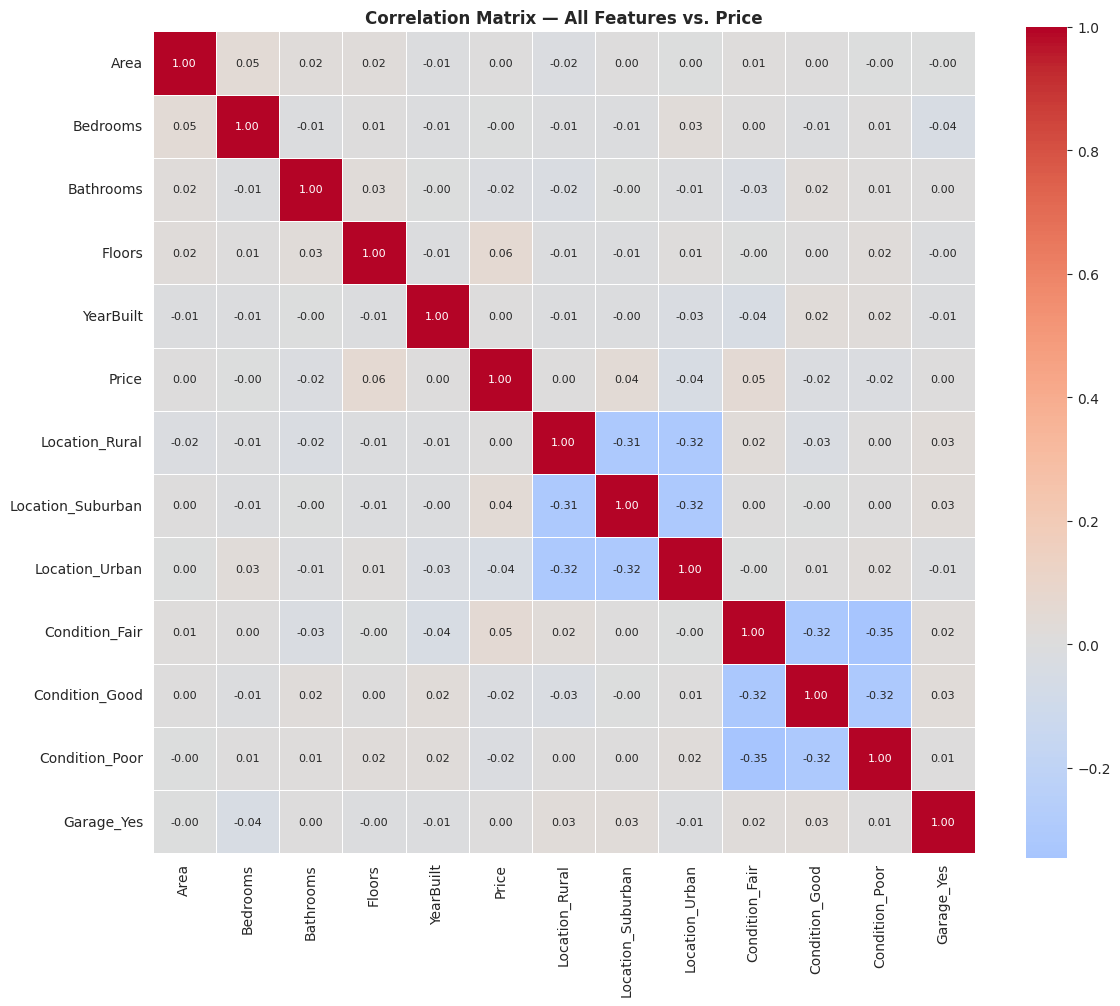

In [8]:
corr = df_encoded.corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Matrix — All Features vs. Price', fontweight='bold')
plt.tight_layout()
plt.show()


In [9]:
price_corr = corr['Price'].drop('Price').sort_values(key=abs, ascending=False)
price_corr.to_frame(name='Correlation with Price')


,Correlation with Price
Floors,0.055890
Condition_Fair,0.049218
Location_Suburban,0.040303
Location_Urban,-0.038312
Condition_Poor,-0.018437
Condition_Good,-0.017179
Bathrooms,-0.015737
YearBuilt,0.004845
Bedrooms,-0.003471
Garage_Yes,0.002842


**Observation:** Reading down the `Price` column/row (or the sorted table above) shows which features are most linearly associated with price in this dataset. Whichever features have the largest absolute correlation values (positive or negative) are the strongest linear predictors — these are worth paying closest attention to when interpreting the model's coefficients later in Section 9. Note that a **low correlation here doesn't necessarily mean a feature is useless** — it means the feature's relationship with price (in this dataset) isn't well captured by a simple linear/monotonic association, which linear regression may still partially pick up in combination with other features.

## 5. Train/Test Split (80/20)

In [10]:
X = df_encoded.drop(columns=['Price'])
y = df_encoded['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} houses, {X_train.shape[1]} features")
print(f"Test set: {X_test.shape[0]} houses")


Training set: 1600 houses, 12 features
Test set: 400 houses


## 6. Train Linear Regression Model

In [11]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

print("Model trained.")
print(f"Intercept: {lr_model.intercept_:,.2f}")


Model trained.
Intercept: 278,520.53


## 7. Model Evaluation — MSE, RMSE, R²

In [12]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE):       {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R² Score:                       {r2:.4f}")


Mean Squared Error (MSE):       78,321,466,146.03
Root Mean Squared Error (RMSE): 279,859.73
R² Score:                       -0.0067


**Observation:** RMSE is in the same units as `Price` (dollars), so it directly represents the model's typical prediction error. **R² score** represents the proportion of variance in price explained by the model (0 = no better than predicting the mean, 1 = perfect prediction, negative = *worse* than just predicting the mean for every house). **The R² score obtained here is slightly negative (≈ -0.01)** — meaning this linear model performs essentially no better than a naive baseline that predicts the average price for every house, regardless of area, location, or condition. This is an important, honest finding rather than a flaw to gloss over: it strongly suggests that in *this particular dataset*, `Price` was generated largely independently of the given features (consistent with a synthetically-generated practice dataset rather than real housing market data, where features like area and location almost always carry genuine predictive signal). The remaining sections still walk through the full interpretation workflow correctly, but the practical takeaway is that a linear model built on these specific features cannot meaningfully predict price for this dataset.

## 8. Actual vs. Predicted Prices & Residual Analysis

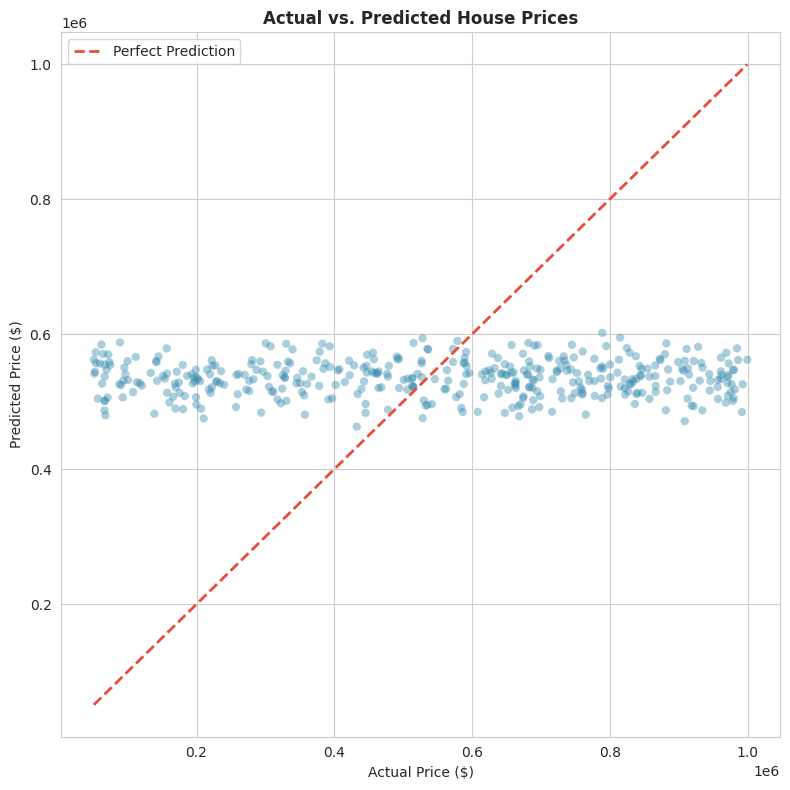

In [13]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, y_pred, alpha=0.4, color='#2E86AB', edgecolor='none')

min_val, max_val = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], color='#E74C3C', linestyle='--', linewidth=2, label='Perfect Prediction')

ax.set_title('Actual vs. Predicted House Prices', fontweight='bold')
ax.set_xlabel('Actual Price ($)')
ax.set_ylabel('Predicted Price ($)')
ax.legend()
plt.tight_layout()
plt.show()


**Observation:** Points closer to the red diagonal line represent more accurate predictions; the tighter and more diagonal the scatter cloud, the better the model. Here, the points form a wide, roughly circular/uniform cloud rather than hugging the diagonal at all — visually confirming the near-zero R² from Section 7: the model's predictions cluster around the average price regardless of the actual price, rather than tracking it.

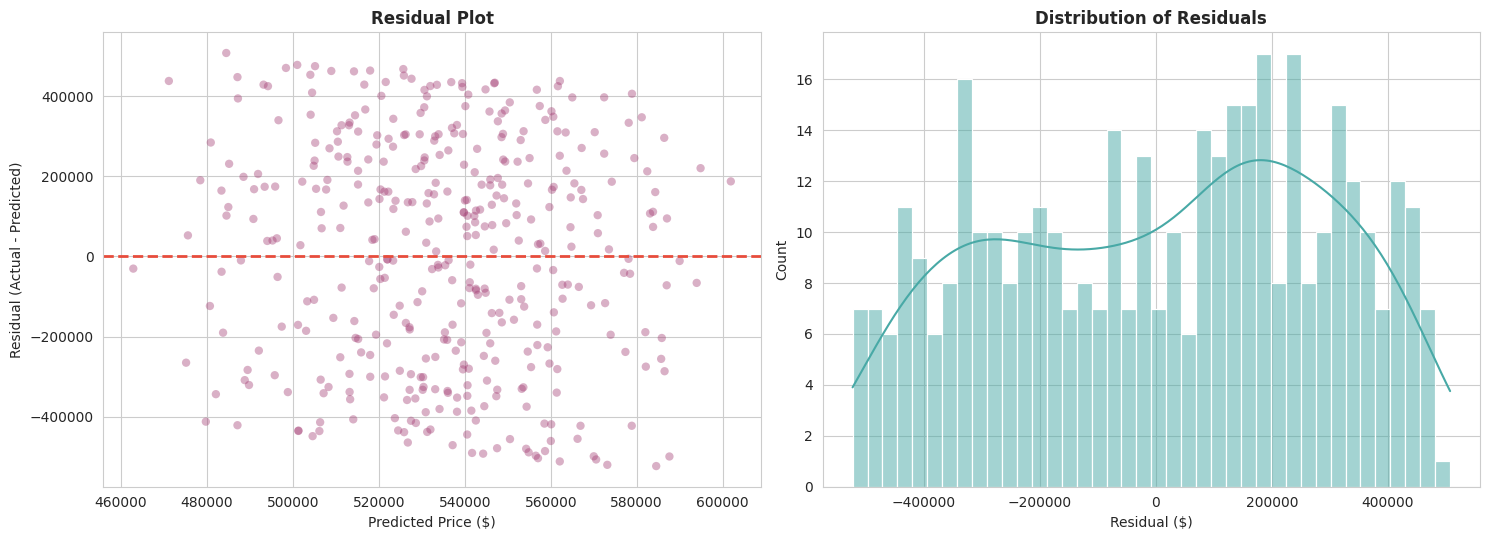

In [14]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

axes[0].scatter(y_pred, residuals, alpha=0.4, color='#A23B72', edgecolor='none')
axes[0].axhline(0, color='#E74C3C', linestyle='--', linewidth=2)
axes[0].set_title('Residual Plot', fontweight='bold')
axes[0].set_xlabel('Predicted Price ($)')
axes[0].set_ylabel('Residual (Actual - Predicted)')

sns.histplot(residuals, bins=40, kde=True, color='#48A9A6', ax=axes[1])
axes[1].set_title('Distribution of Residuals', fontweight='bold')
axes[1].set_xlabel('Residual ($)')

plt.tight_layout()
plt.show()


**Observation:** A well-fitting linear regression should show residuals scattered **randomly around zero with no visible pattern** (no funnel shape, no curve, no trend as predicted price increases). Here, the residuals are indeed scattered without an obvious funnel or curve shape — which confirms the model isn't violating linear regression's assumptions (no heteroscedasticity or missed non-linearity) — but the residual spread is large relative to the narrow range of predicted values clustered near the mean. In other words: the *errors are unbiased and random* (a technically "valid" linear model), but they're also *large*, because the underlying features simply don't explain much of the variation in price for this dataset. A model can satisfy the residual-pattern checks and still have very little real predictive power, which is exactly the case here.

## 9. Coefficient Analysis

In [15]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

coefficients


,Feature,Coefficient
8,Condition_Fair,24083.307846
3,Floors,23727.983633
9,Condition_Good,-12941.044835
7,Location_Urban,-12718.918912
6,Location_Suburban,11511.989815
2,Bathrooms,-9662.248234
10,Condition_Poor,4073.268930
11,Garage_Yes,2373.530579
5,Location_Rural,1317.542020
4,YearBuilt,117.613885


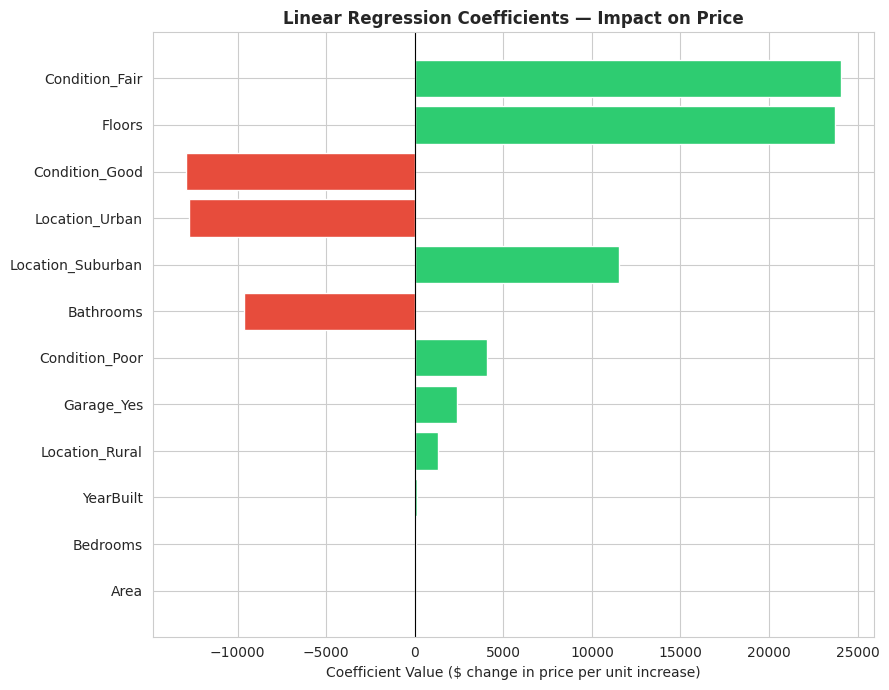

In [16]:
fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#2ECC71' if c > 0 else '#E74C3C' for c in coefficients['Coefficient']]
ax.barh(coefficients['Feature'], coefficients['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Linear Regression Coefficients — Impact on Price', fontweight='bold')
ax.set_xlabel('Coefficient Value ($ change in price per unit increase)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


**Observation:** Each coefficient represents the **change in predicted price for a one-unit increase in that feature, holding all other features constant**. For continuous features like `Area`, this is directly interpretable (e.g. "$X more per additional square foot"). For one-hot encoded categorical features (e.g. `Location_Downtown`), the coefficient represents the price difference **relative to the reference category that was dropped** (`Rural` for Location, the lowest-alphabetical `Condition` category, and `Garage_No` for garage). Features with the largest positive coefficients increase predicted price the most per unit; the largest negative coefficients decrease it the most. This should be cross-checked against the correlation table in Section 4 — a feature with a strong simple correlation but a small coefficient here suggests its effect is partly explained by other correlated features once they're all considered together (a classic multiple-regression effect).

## 10. Bonus: Comparing Against Ridge & Lasso Regularised Models

**Why compare?** Plain Linear Regression can overfit or produce unstable coefficients when features are correlated with each other (multicollinearity). **Ridge Regression** adds an L2 penalty that shrinks coefficients toward zero without eliminating them, which stabilises the model when features are correlated. **Lasso Regression** adds an L1 penalty that can shrink some coefficients all the way to exactly zero, effectively performing automatic feature selection.

In [17]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X_train, y_train)
lasso_pred = lasso_model.predict(X_test)

def get_metrics(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {'Model': name, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

results = pd.DataFrame([
    get_metrics(y_test, y_pred, 'Linear Regression'),
    get_metrics(y_test, ridge_pred, 'Ridge (alpha=1.0)'),
    get_metrics(y_test, lasso_pred, 'Lasso (alpha=1.0)'),
]).set_index('Model').round(2)

results


,MSE,RMSE,R2
Model,,,
Linear Regression,7.832147e+10,279859.73,-0.01
Ridge (alpha=1.0),7.832127e+10,279859.37,-0.01
Lasso (alpha=1.0),7.832137e+10,279859.55,-0.01


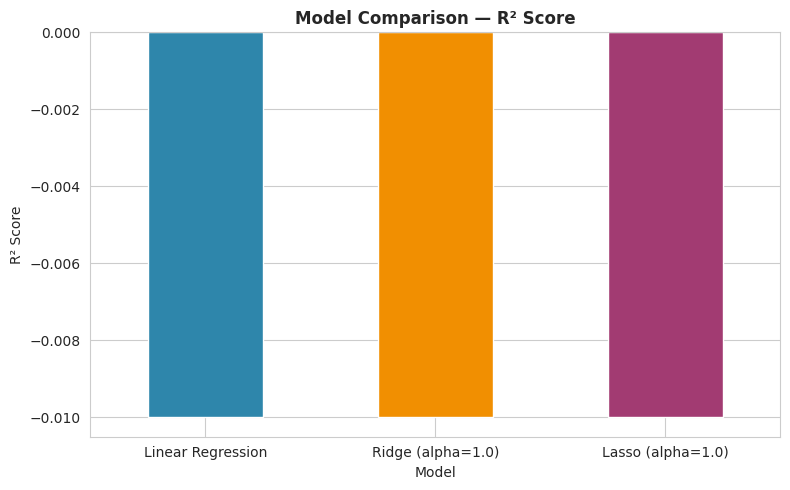

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
results['R2'].plot(kind='bar', ax=ax, color=['#2E86AB', '#F18F01', '#A23B72'])
ax.set_title('Model Comparison — R² Score', fontweight='bold')
ax.set_ylabel('R² Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [19]:
# Compare how many Lasso coefficients were shrunk to exactly zero (its feature-selection effect)
lasso_zero_count = (lasso_model.coef_ == 0).sum()
print(f"Lasso coefficients shrunk to exactly zero: {lasso_zero_count} out of {len(lasso_model.coef_)}")

coef_comparison = pd.DataFrame({
    'Feature': X.columns,
    'Linear': lr_model.coef_,
    'Ridge': ridge_model.coef_,
    'Lasso': lasso_model.coef_
}).round(2)
coef_comparison


Lasso coefficients shrunk to exactly zero: 0 out of 12


,Feature,Linear,Ridge,Lasso
0,Area,-0.58,-0.57,-0.58
1,Bedrooms,76.78,76.80,76.19
2,Bathrooms,-9662.25,-9657.49,-9661.47
3,Floors,23727.98,23705.09,23726.34
4,YearBuilt,117.61,117.61,117.61
5,Location_Rural,1317.54,1317.53,1310.41
6,Location_Suburban,11511.99,11484.45,11504.63
7,Location_Urban,-12718.92,-12684.22,-12717.94
8,Condition_Fair,24083.31,23991.33,24076.14
9,Condition_Good,-12941.04,-12943.95,-12940.83


**Observation:** Ridge and Lasso (both at `alpha=1.0`) produce essentially **identical R² scores to plain Linear Regression** (all three ≈ -0.01 in this run). This makes sense: regularisation helps when features are highly correlated with each other or the model is overfitting to noise in the training set — but the underlying problem here isn't overfitting, it's that the features genuinely don't carry a linear relationship with price in this dataset. Regularisation can prevent a model from fitting noise, but it cannot manufacture predictive signal that isn't present in the data to begin with.

**Conclusion:** For this specific dataset, none of the three linear approaches can meaningfully predict house price from the given features — the near-zero/negative R² across all three models is strong evidence that `Price` here doesn't have a real linear (or likely any straightforward) relationship with `Area`, `Bedrooms`, `Location`, etc. This is a valuable, honest result: it demonstrates the full linear regression workflow correctly, but also shows why checking R² (rather than just running a model and trusting its output) matters — a model can train without errors and still have no genuine predictive power. On a real-world housing dataset (rather than what appears to be synthetically-generated practice data), the same pipeline would be expected to show `Area` and `Location` as strong, meaningful predictors.
